# 03 Models Salem Part

In [1]:
# Imports and setup

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

RANDOM_STATE = 42
TARGET_COL = "DEATH_EVENT"

# This makes the notebook work from either the project folder or the notebooks folder.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

TABLES_DIR = PROJECT_ROOT / "results" / "tables"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Tables folder:", TABLES_DIR)
print("Metrics folder:", METRICS_DIR)
print("Figures folder:", FIGURES_DIR)


Project root: c:\Users\salem\Desktop\CS439\CS439-Project
Tables folder: c:\Users\salem\Desktop\CS439\CS439-Project\results\tables
Metrics folder: c:\Users\salem\Desktop\CS439\CS439-Project\results\metrics
Figures folder: c:\Users\salem\Desktop\CS439\CS439-Project\results\figures


In [2]:
def load_table(file_name: str) -> pd.DataFrame:
    """Load a CSV file from results/tables."""
    file_path = TABLES_DIR / file_name

    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

    return pd.read_csv(file_path)


def load_y(file_name: str) -> pd.Series:
    """Load y_train or y_test safely, even if the CSV column name is different."""
    file_path = TABLES_DIR / file_name

    if not file_path.exists() or file_path.stat().st_size == 0:
        print(f"{file_name} is missing or empty. Trying to rebuild y from the raw dataset.")
        return rebuild_y_from_raw(file_name)

    y_df = pd.read_csv(file_path)

    if y_df.empty or y_df.shape[1] == 0:
        print(f"{file_name} did not load correctly. Trying to rebuild y from the raw dataset.")
        return rebuild_y_from_raw(file_name)

    if TARGET_COL in y_df.columns:
        y = y_df[TARGET_COL]
    else:
        # If the file has one unnamed column, this still works.
        y = y_df.iloc[:, -1]

    return y.astype(int).reset_index(drop=True)


def find_raw_dataset() -> Path:
    """Find the original heart failure CSV if y needs to be rebuilt."""
    possible_paths = [
        PROJECT_ROOT / "data" / "heart_failure_clinical_records_dataset.csv",
        PROJECT_ROOT / "data" / "heart_failure_clinical_records_dataset(4).csv",
        PROJECT_ROOT / "heart_failure_clinical_records_dataset.csv",
        PROJECT_ROOT / "heart_failure_clinical_records_dataset(4).csv",
        Path("/mnt/data/heart_failure_clinical_records_dataset(4).csv"),
        Path("/mnt/data/heart_failure_clinical_records_dataset.csv"),
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError("Could not find the raw heart failure dataset.")


def rebuild_y_from_raw(file_name: str) -> pd.Series:
    """Rebuild y_train or y_test using the saved train/test split indices."""
    raw_path = find_raw_dataset()
    df_raw = pd.read_csv(raw_path).drop_duplicates().reset_index(drop=True)

    if TARGET_COL not in df_raw.columns:
        raise ValueError(f"Could not find {TARGET_COL} in the raw dataset.")

    split_path = TABLES_DIR / "train_test_split_indices.csv"

    if not split_path.exists():
        raise FileNotFoundError(
            "y file is missing/empty and train_test_split_indices.csv was not found."
        )

    split_info = pd.read_csv(split_path)

    if "original_index" not in split_info.columns or "split" not in split_info.columns:
        raise ValueError(
            "train_test_split_indices.csv must have columns: original_index and split."
        )

    if file_name == "y_train.csv":
        needed_indices = split_info.loc[split_info["split"] == "train", "original_index"].to_numpy()
    elif file_name == "y_test.csv":
        needed_indices = split_info.loc[split_info["split"] == "test", "original_index"].to_numpy()
    else:
        raise ValueError("file_name must be y_train.csv or y_test.csv")

    y = df_raw.loc[needed_indices, TARGET_COL].astype(int).reset_index(drop=True)
    return y


def evaluate_model(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str, time_version: str) -> dict:
    """Evaluate one model and return the main metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results = {
        "model": model_name,
        "time_version": time_version,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    return results


def save_confusion_matrix(model, X_test: pd.DataFrame, y_test: pd.Series, file_stem: str) -> None:
    """Save a confusion matrix plot."""
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived", "Death"])
    disp.plot()
    plt.title(file_stem.replace("_", " ").title())
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"confusion_matrix_{file_stem}.png", dpi=300)
    plt.show()


def save_roc_curve(model, X_test: pd.DataFrame, y_test: pd.Series, file_stem: str) -> None:
    """Save a ROC curve plot."""
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(file_stem.replace("_", " ").title())
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"roc_{file_stem}.png", dpi=300)
    plt.show()


## Load preprocessed data



In [3]:
# Salem Part files

X_train_lr_with_time = load_table("X_train_lr_with_time.csv")
X_test_lr_with_time = load_table("X_test_lr_with_time.csv")

X_train_lr_without_time = load_table("X_train_lr_without_time.csv")
X_test_lr_without_time = load_table("X_test_lr_without_time.csv")

X_train_rf_with_time = load_table("X_train_rf_with_time.csv")
X_test_rf_with_time = load_table("X_test_rf_with_time.csv")

X_train_rf_without_time = load_table("X_train_rf_without_time.csv")
X_test_rf_without_time = load_table("X_test_rf_without_time.csv")

y_train = load_y("y_train.csv")
y_test = load_y("y_test.csv")

print("X_train_lr_with_time:", X_train_lr_with_time.shape)
print("X_test_lr_with_time:", X_test_lr_with_time.shape)
print("X_train_lr_without_time:", X_train_lr_without_time.shape)
print("X_test_lr_without_time:", X_test_lr_without_time.shape)

print("X_train_rf_with_time:", X_train_rf_with_time.shape)
print("X_test_rf_with_time:", X_test_rf_with_time.shape)
print("X_train_rf_without_time:", X_train_rf_without_time.shape)
print("X_test_rf_without_time:", X_test_rf_without_time.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train_lr_with_time: (239, 12)
X_test_lr_with_time: (60, 12)
X_train_lr_without_time: (239, 11)
X_test_lr_without_time: (60, 11)
X_train_rf_with_time: (239, 12)
X_test_rf_with_time: (60, 12)
X_train_rf_without_time: (239, 11)
X_test_rf_without_time: (60, 11)
y_train: (239,)
y_test: (60,)


In [4]:
# Quick checks before training

assert len(X_train_lr_with_time) == len(y_train)
assert len(X_train_lr_without_time) == len(y_train)
assert len(X_train_rf_with_time) == len(y_train)
assert len(X_train_rf_without_time) == len(y_train)

assert len(X_test_lr_with_time) == len(y_test)
assert len(X_test_lr_without_time) == len(y_test)
assert len(X_test_rf_with_time) == len(y_test)
assert len(X_test_rf_without_time) == len(y_test)

assert "time" in X_train_lr_with_time.columns
assert "time" not in X_train_lr_without_time.columns
assert "time" in X_train_rf_with_time.columns
assert "time" not in X_train_rf_without_time.columns

print("All shapes and time-column checks passed.")
print("\nTraining target counts:")
print(y_train.value_counts())
print("\nTesting target counts:")
print(y_test.value_counts())


All shapes and time-column checks passed.

Training target counts:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64

Testing target counts:
DEATH_EVENT
0    41
1    19
Name: count, dtype: int64



## Model 1: Logistic Regression


In [5]:
# Logistic Regression with time

logistic_with_time = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

logistic_with_time.fit(X_train_lr_with_time, y_train)

logistic_with_time_results = evaluate_model(
    logistic_with_time,
    X_test_lr_with_time,
    y_test,
    model_name="Logistic Regression",
    time_version="with_time",
)

logistic_with_time_results


{'model': 'Logistic Regression',
 'time_version': 'with_time',
 'accuracy': 0.8,
 'precision': 0.7333333333333333,
 'recall': 0.5789473684210527,
 'f1': 0.6470588235294118,
 'roc_auc': 0.8575096277278563}

In [6]:
# Classification report for Logistic Regression with time

y_pred_logistic_with_time = logistic_with_time.predict(X_test_lr_with_time)

print(classification_report(
    y_test,
    y_pred_logistic_with_time,
    target_names=["Survived", "Death"],
    zero_division=0,
))


              precision    recall  f1-score   support

    Survived       0.82      0.90      0.86        41
       Death       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60



In [7]:
# Logistic Regression without time

logistic_without_time = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

logistic_without_time.fit(X_train_lr_without_time, y_train)

logistic_without_time_results = evaluate_model(
    logistic_without_time,
    X_test_lr_without_time,
    y_test,
    model_name="Logistic Regression",
    time_version="without_time",
)

logistic_without_time_results


{'model': 'Logistic Regression',
 'time_version': 'without_time',
 'accuracy': 0.7,
 'precision': 0.5263157894736842,
 'recall': 0.5263157894736842,
 'f1': 0.5263157894736842,
 'roc_auc': 0.7406931964056482}

In [8]:
# Classification report for Logistic Regression without time

y_pred_logistic_without_time = logistic_without_time.predict(X_test_lr_without_time)

print(classification_report(
    y_test,
    y_pred_logistic_without_time,
    target_names=["Survived", "Death"],
    zero_division=0,
))


              precision    recall  f1-score   support

    Survived       0.78      0.78      0.78        41
       Death       0.53      0.53      0.53        19

    accuracy                           0.70        60
   macro avg       0.65      0.65      0.65        60
weighted avg       0.70      0.70      0.70        60



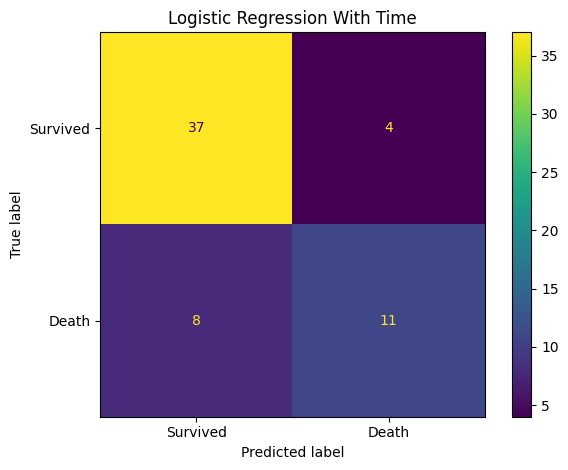

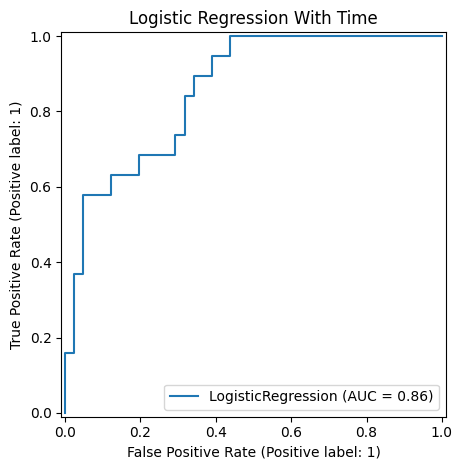

In [9]:
save_confusion_matrix(
    logistic_with_time,
    X_test_lr_with_time,
    y_test,
    "logistic_regression_with_time",
)

save_roc_curve(
    logistic_with_time,
    X_test_lr_with_time,
    y_test,
    "logistic_regression_with_time",
)


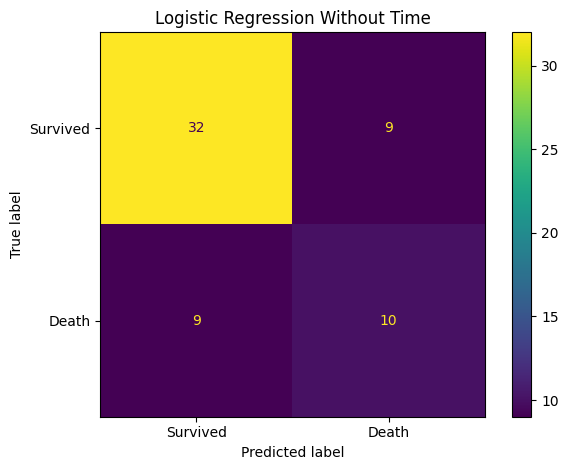

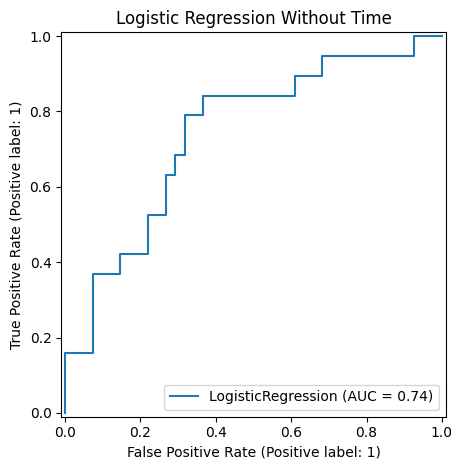

In [10]:
save_confusion_matrix(
    logistic_without_time,
    X_test_lr_without_time,
    y_test,
    "logistic_regression_without_time",
)

save_roc_curve(
    logistic_without_time,
    X_test_lr_without_time,
    y_test,
    "logistic_regression_without_time",
)


## Model 2: Random Forest



In [11]:
# Random Forest with time

random_forest_with_time = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

random_forest_with_time.fit(X_train_rf_with_time, y_train)

random_forest_with_time_results = evaluate_model(
    random_forest_with_time,
    X_test_rf_with_time,
    y_test,
    model_name="Random Forest",
    time_version="with_time",
)

random_forest_with_time_results


{'model': 'Random Forest',
 'time_version': 'with_time',
 'accuracy': 0.8333333333333334,
 'precision': 0.8461538461538461,
 'recall': 0.5789473684210527,
 'f1': 0.6875,
 'roc_auc': 0.8992297817715019}

In [12]:
# Classification report for Random Forest with time

y_pred_rf_with_time = random_forest_with_time.predict(X_test_rf_with_time)

print(classification_report(
    y_test,
    y_pred_rf_with_time,
    target_names=["Survived", "Death"],
    zero_division=0,
))


              precision    recall  f1-score   support

    Survived       0.83      0.95      0.89        41
       Death       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60



In [13]:
# Random Forest without time

random_forest_without_time = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

random_forest_without_time.fit(X_train_rf_without_time, y_train)

random_forest_without_time_results = evaluate_model(
    random_forest_without_time,
    X_test_rf_without_time,
    y_test,
    model_name="Random Forest",
    time_version="without_time",
)

random_forest_without_time_results


{'model': 'Random Forest',
 'time_version': 'without_time',
 'accuracy': 0.7333333333333333,
 'precision': 0.6153846153846154,
 'recall': 0.42105263157894735,
 'f1': 0.5,
 'roc_auc': 0.7965340179717587}

In [14]:
# Classification report for Random Forest without time

y_pred_rf_without_time = random_forest_without_time.predict(X_test_rf_without_time)

print(classification_report(
    y_test,
    y_pred_rf_without_time,
    target_names=["Survived", "Death"],
    zero_division=0,
))


              precision    recall  f1-score   support

    Survived       0.77      0.88      0.82        41
       Death       0.62      0.42      0.50        19

    accuracy                           0.73        60
   macro avg       0.69      0.65      0.66        60
weighted avg       0.72      0.73      0.72        60



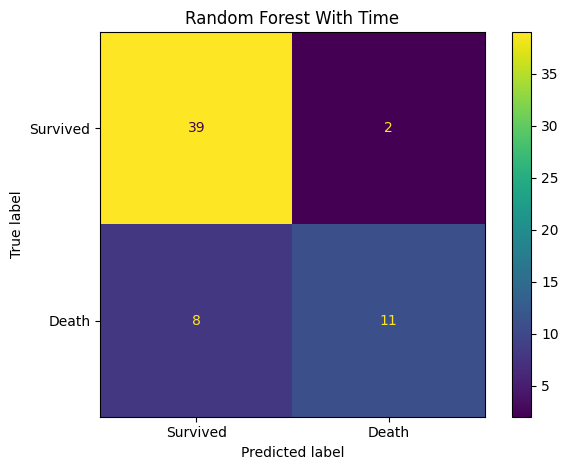

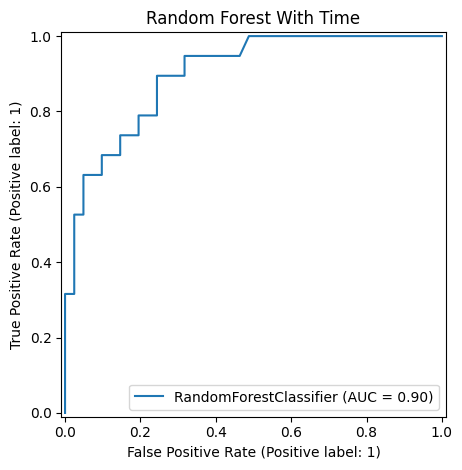

In [15]:
save_confusion_matrix(
    random_forest_with_time,
    X_test_rf_with_time,
    y_test,
    "random_forest_with_time",
)

save_roc_curve(
    random_forest_with_time,
    X_test_rf_with_time,
    y_test,
    "random_forest_with_time",
)


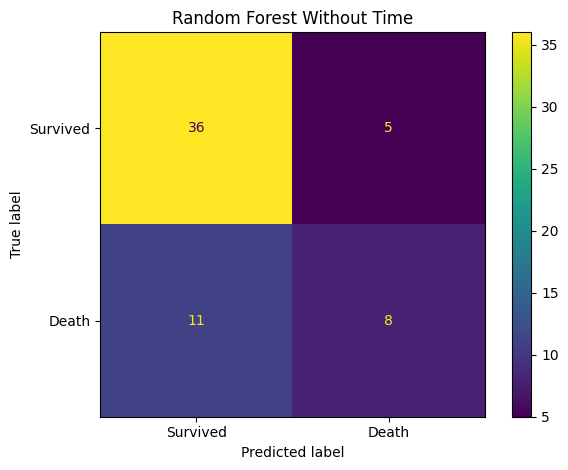

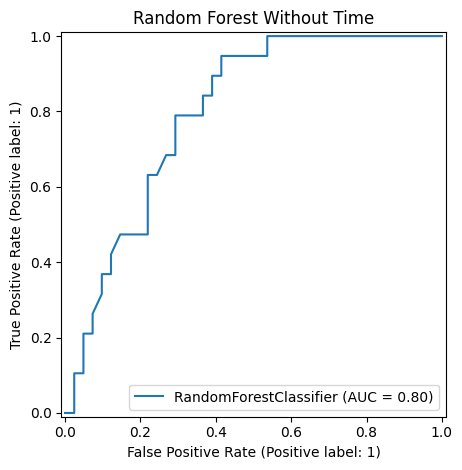

In [16]:
save_confusion_matrix(
    random_forest_without_time,
    X_test_rf_without_time,
    y_test,
    "random_forest_without_time",
)

save_roc_curve(
    random_forest_without_time,
    X_test_rf_without_time,
    y_test,
    "random_forest_without_time",
)


In [17]:
salem_results = pd.DataFrame([
    logistic_with_time_results,
    logistic_without_time_results,
    random_forest_with_time_results,
    random_forest_without_time_results,
])

salem_results = salem_results[
    ["model", "time_version", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

salem_results_path = METRICS_DIR / "salem_logistic_randomforest_metrics.csv"
salem_results.to_csv(salem_results_path, index=False)

print("Saved Salem results to:", salem_results_path)
salem_results


Saved Salem results to: c:\Users\salem\Desktop\CS439\CS439-Project\results\metrics\salem_logistic_randomforest_metrics.csv


,model,time_version,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,with_time,0.800000,0.733333,0.578947,0.647059,0.857510
1,Logistic Regression,without_time,0.700000,0.526316,0.526316,0.526316,0.740693
2,Random Forest,with_time,0.833333,0.846154,0.578947,0.687500,0.899230
3,Random Forest,without_time,0.733333,0.615385,0.421053,0.500000,0.796534


In [18]:
# Simple automatic summary for my part

best_by_recall = salem_results.sort_values("recall", ascending=False).iloc[0]
best_by_auc = salem_results.sort_values("roc_auc", ascending=False).iloc[0]

print("Best Salem model by recall:")
print(best_by_recall)

print("\nBest Salem model by ROC-AUC:")
print(best_by_auc)


Best Salem model by recall:
model           Logistic Regression
time_version              with_time
accuracy                        0.8
precision                  0.733333
recall                     0.578947
f1                         0.647059
roc_auc                     0.85751
Name: 0, dtype: object

Best Salem model by ROC-AUC:
model           Random Forest
time_version        with_time
accuracy             0.833333
precision            0.846154
recall               0.578947
f1                     0.6875
roc_auc               0.89923
Name: 2, dtype: object
